# Part 03: Ice Detection & Phenology Analysis
## Memory-Efficient Chunked Processing Version

This notebook processes ~10M S1 observations across 31,108 lakes using a multi-pass 
chunked architecture to avoid memory overflow on 64GB machines.

**Architecture:**
- **Pass 1:** Build training labels (chunked) → ~1-3M labeled S1 observations
- **Pass 2:** Train RF model and save to disk
- **Pass 3:** Predict on all S1 data (streaming write to CSV)
- **Pass 4:** Detect ice phenology (chunked by spatial chunks)
- **Pass 5:** Upload results to GCS

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from google.cloud import storage
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import warnings
import joblib
import os

# Suppress expected warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Output paths
os.makedirs('./figures/working', exist_ok=True)
os.makedirs('./figures/manuscript', exist_ok=True)
os.makedirs('./figure_data', exist_ok=True)

RESULTS_GCS = 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'

print("Libraries loaded")

/opt/conda/envs/gee/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Libraries loaded


In [2]:
# GCS Export Setup - Install and verify gcsfs
try:
    import gcsfs
    fs = gcsfs.GCSFileSystem()
    print("gcsfs already installed and configured")
except ImportError:
    print("Installing gcsfs...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'gcsfs', '-q'])
    import gcsfs
    fs = gcsfs.GCSFileSystem()
    print("gcsfs installed successfully")

gcsfs already installed and configured


## Configuration

In [3]:
# ============================================================
# DATA CONFIGURATION
# ============================================================
BUCKET_NAME = 'wustl-eeps-geospatial'
EXPORT_PREFIX = 'thermokarst_lakes/exports'
CHUNKS_PATH = 'thermokarst_lakes/processed/chunks'

YEARS = [2019, 2020, 2021, 2022, 2023]
NUM_CHUNKS = 21  # Chunks 0-20 (spatial chunks)

# Initialize GCS client
storage_client = storage.Client()
bucket = storage_client.bucket(BUCKET_NAME)

# ============================================================
# LABELING THRESHOLDS
# ============================================================
# S2 NDSI thresholds
S2_CLOUD_THRESHOLD = 30  # Maximum cloud percentage to accept
ICE_THRESHOLD_HIGH = 0.8  # s2_ice_fraction > this → ICE label
WATER_THRESHOLD_LOW = 0.2  # s2_ice_fraction < this → WATER label

# Temperature thresholds for sustained periods (training labels)
TEMP_SUSTAINED_COLD = -20  # 10+ consecutive days below → ICE label
TEMP_SUSTAINED_WARM = 10   # 10+ consecutive days above → WATER label
CONSECUTIVE_DAYS = 10

# Temperature conflict thresholds (single-day, for excluding S2)
TEMP_CONFLICT_COLD = -5    # S2 "water" on a day below this → exclude
TEMP_CONFLICT_WARM = 5     # S2 "ice" on a day above this → exclude

# ============================================================
# INFERENCE CONFIGURATION
# ============================================================
# S2 override during inference: Set to False for RF-only classification
# When False, all ice state classifications come from RF model only
# (S2 is still used for TRAINING labels, just not inference overrides)
USE_S2_OVERRIDE = False  # Changed from True to simplify methodology

# ============================================================
# RF MODEL FEATURES
# ============================================================
FEATURE_COLS = [
    'lake_vv_db', 'lake_vh_db', 'lake_vv_vh_ratio',
    'land_vv_db', 'land_vh_db', 'land_vv_vh_ratio'
]

# ============================================================
# PHENOLOGY CONFIGURATION
# ============================================================
MIN_CONSECUTIVE_OBS = 2
ICE_OFF_START_DATE = '04-01'  # April 1 (DOY 91)
ICE_OFF_END_DATE = '08-31'    # August 31 (DOY 243) - prevents overlap with ice-on search
ICE_ON_START_DATE = '09-01'   # September 1 (DOY 244)

# ============================================================
# OUTPUT FILE PATHS
# ============================================================
LOCAL_TIMESERIES_PATH = 'alaska_lakes_ice_probability_timeseries_2019-2023.csv'
LOCAL_PHENOLOGY_PATH = 'alaska_lakes_ice_phenology_2019-2023.csv'
LOCAL_MODEL_PATH = 'rf_ice_model.joblib'
LOCAL_TRAINING_PATH = 'training_data.parquet'

print(f"Configuration loaded:")
print(f"  Years: {YEARS}")
print(f"  Chunks: {NUM_CHUNKS}")
print(f"  Features: {FEATURE_COLS}")
print(f"  USE_S2_OVERRIDE: {USE_S2_OVERRIDE}")

Configuration loaded:
  Years: [2019, 2020, 2021, 2022, 2023]
  Chunks: 21
  Features: ['lake_vv_db', 'lake_vh_db', 'lake_vv_vh_ratio', 'land_vv_db', 'land_vh_db', 'land_vv_vh_ratio']
  USE_S2_OVERRIDE: False


## Data Loading Functions (Chunked)

In [4]:
def load_chunk_data(sensor, year, chunk_id):
    """
    Load a single chunk-year of sensor data from GCS.
    
    Parameters:
    -----------
    sensor : str - 's1', 's2', or 'era5'
    year : int - Year (2019-2023)
    chunk_id : int - Chunk index (0-20)
    
    Returns:
    --------
    pd.DataFrame or None if file doesn't exist
    """
    path = f'gs://{BUCKET_NAME}/{EXPORT_PREFIX}/{year}/chunk_{chunk_id:02d}/{sensor}_data.csv'
    try:
        df = pd.read_csv(path)
        df['year'] = year
        df['chunk'] = chunk_id
        
        # Convert date columns
        date_col = f'{sensor}_date'
        if date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col])
        
        return df
    except Exception as e:
        return None

def load_morphometry():
    """Load lake morphometry from chunk files (small, ~31K lakes)."""
    morphometry_chunks = []
    
    for chunk_id in range(NUM_CHUNKS):
        chunk_path = f'gs://{BUCKET_NAME}/{CHUNKS_PATH}/chunk_{chunk_id:02d}.geojson'
        try:
            chunk_gdf = gpd.read_file(chunk_path)
            chunk_gdf['chunk'] = chunk_id
            morphometry_chunks.append(chunk_gdf)
        except Exception as e:
            print(f"  Warning: Could not load chunk {chunk_id:02d}: {e}")
            continue
    
    if len(morphometry_chunks) == 0:
        raise FileNotFoundError("Could not load any chunk files!")
    
    morphometry_gdf = pd.concat(morphometry_chunks, ignore_index=True)
    
    # Rename columns to match expected names
    # Actual columns: id, lake_area_km2, shoreline_dev, circularity, convexity, centroid_lon, centroid_lat
    morphometry_gdf = morphometry_gdf.rename(columns={
        'id': 'lake_id',
        'lake_area_km2': 'area_km2',
        'shoreline_dev': 'sdi'
    })
    
    # Select relevant columns
    morphometry_cols = ['lake_id', 'area_km2', 'circularity', 'sdi', 'convexity', 
                        'centroid_lon', 'centroid_lat', 'chunk']
    morphometry = morphometry_gdf[morphometry_cols].copy()
    
    print(f"Loaded morphometry for {len(morphometry):,} lakes from {len(morphometry_chunks)} chunks")
    return morphometry

print("Data loading functions defined")

Data loading functions defined


## Label Creation Functions

In [5]:
def identify_sustained_temp_labels(era5_df, cold_thresh, warm_thresh, min_consecutive):
    """
    Create training labels from sustained temperature periods.
    
    Returns DataFrame with columns ['lake_id', 'date', 'temp_label']
    """
    temp_labels = []
    
    for lake_id, lake_df in era5_df.groupby('id'):
        lake_df = lake_df.sort_values('era5_date').copy()
        
        # Identify cold periods (< cold_thresh)
        lake_df['is_cold'] = lake_df['temp_c'] < cold_thresh
        lake_df['cold_group'] = (~lake_df['is_cold']).cumsum()
        
        cold_periods = lake_df[lake_df['is_cold']].groupby('cold_group').filter(
            lambda x: len(x) >= min_consecutive
        )
        
        for _, row in cold_periods.iterrows():
            temp_labels.append({
                'lake_id': lake_id,
                'date': row['era5_date'],
                'temp_label': 'ice'
            })
        
        # Identify warm periods (> warm_thresh)
        lake_df['is_warm'] = lake_df['temp_c'] > warm_thresh
        lake_df['warm_group'] = (~lake_df['is_warm']).cumsum()
        
        warm_periods = lake_df[lake_df['is_warm']].groupby('warm_group').filter(
            lambda x: len(x) >= min_consecutive
        )
        
        for _, row in warm_periods.iterrows():
            temp_labels.append({
                'lake_id': lake_id,
                'date': row['era5_date'],
                'temp_label': 'water'
            })
    
    return pd.DataFrame(temp_labels)

def create_s2_labels_with_conflict_detection(s2_df, era5_df, ice_thresh, water_thresh,
                                             conflict_cold, conflict_warm, cloud_thresh):
    """
    Create S2 NDSI labels with temperature conflict detection.
    
    Returns DataFrame with columns ['lake_id', 'date', 's2_label']
    """
    # Filter for low cloud
    s2_clean = s2_df[s2_df['s2_cloud_pct'] <= cloud_thresh].copy()
    
    # Create S2 labels based on NDSI thresholds
    s2_clean['s2_label'] = None
    s2_clean.loc[s2_clean['s2_ice_fraction'] >= ice_thresh, 's2_label'] = 'ice'
    s2_clean.loc[s2_clean['s2_ice_fraction'] <= water_thresh, 's2_label'] = 'water'
    
    # Keep only labeled observations
    s2_labeled = s2_clean[s2_clean['s2_label'].notna()].copy()
    s2_labeled['date'] = s2_labeled['s2_date'].dt.normalize()
    
    # Merge with ERA5 temperature for conflict detection
    era5_for_merge = era5_df[['id', 'era5_date', 'temp_c']].copy()
    era5_for_merge['date'] = era5_for_merge['era5_date'].dt.normalize()
    era5_for_merge = era5_for_merge.rename(columns={'id': 'lake_id'})
    
    s2_with_temp = s2_labeled.merge(
        era5_for_merge[['lake_id', 'date', 'temp_c']],
        left_on=['id', 'date'],
        right_on=['lake_id', 'date'],
        how='left'
    )
    
    # Identify conflicts
    s2_with_temp['conflict'] = False
    # S2 says water but temp is very cold
    s2_with_temp.loc[(s2_with_temp['s2_label'] == 'water') & 
                     (s2_with_temp['temp_c'] < conflict_cold), 'conflict'] = True
    # S2 says ice but temp is warm
    s2_with_temp.loc[(s2_with_temp['s2_label'] == 'ice') & 
                     (s2_with_temp['temp_c'] > conflict_warm), 'conflict'] = True
    
    # Keep only non-conflicting labels
    s2_clean_labels = s2_with_temp[~s2_with_temp['conflict']][['id', 'date', 's2_label']].copy()
    s2_clean_labels = s2_clean_labels.rename(columns={'id': 'lake_id'})
    
    return s2_clean_labels

def create_s1_features(s1_df):
    """Add derived features to S1 data."""
    s1_df = s1_df.copy()
    s1_df['lake_vv_vh_ratio'] = s1_df['lake_vv_db'] - s1_df['lake_vh_db']
    s1_df['land_vv_vh_ratio'] = s1_df['land_vv_db'] - s1_df['land_vh_db']
    s1_df['date'] = s1_df['s1_date'].dt.normalize()
    return s1_df

print("Label creation functions defined")

Label creation functions defined


In [6]:
def detect_ice_phenology(lake_df, min_consecutive=2):
    """
    Detect ice-off and ice-on dates for a single lake.
    
    Parameters:
    -----------
    lake_df : pd.DataFrame - Time series data for one lake, sorted by date
    min_consecutive : int - Minimum consecutive observations to confirm transition
    
    Returns:
    --------
    dict with ice_off/ice_on dates, DOY, confidence, and ice_free_days
    
    Note:
    -----
    Ice-off is only searched for between ICE_OFF_START_DATE (Apr 1) and 
    ICE_OFF_END_DATE (Aug 31) to prevent false detections in fall after
    ice-on has already occurred. This constraint was added to fix ~60 
    anomalous records where ice-off DOY > ice-on DOY.
    """
    lake_df = lake_df.sort_values('date').reset_index(drop=True)
    year = lake_df['date'].iloc[0].year
    
    ice_off_start = pd.Timestamp(f'{year}-{ICE_OFF_START_DATE}')
    ice_off_end = pd.Timestamp(f'{year}-{ICE_OFF_END_DATE}')
    ice_on_start = pd.Timestamp(f'{year}-{ICE_ON_START_DATE}')
    
    result = {
        'ice_off_date': None, 'ice_off_doy': None, 'ice_off_conf': None,
        'ice_on_date': None, 'ice_on_doy': None, 'ice_on_conf': None,
        'ice_free_days': None
    }
    
    # Detect ice-off (first sustained WATER between ice_off_start and ice_off_end)
    # Constrained to Apr 1 - Aug 31 to prevent overlap with ice-on search window
    spring_df = lake_df[(lake_df['date'] >= ice_off_start) & 
                        (lake_df['date'] <= ice_off_end)].copy()
    
    if len(spring_df) >= min_consecutive:
        for i in range(len(spring_df) - min_consecutive + 1):
            window = spring_df.iloc[i:i+min_consecutive]
            if (window['ice_state'] == 'water').all():
                result['ice_off_date'] = window.iloc[0]['date']
                result['ice_off_doy'] = window.iloc[0]['date'].dayofyear
                result['ice_off_conf'] = window.iloc[0]['confidence']
                break
    
    # Detect ice-on (first sustained ICE after ice_on_start)
    fall_df = lake_df[lake_df['date'] >= ice_on_start].copy()
    
    if len(fall_df) >= min_consecutive:
        for i in range(len(fall_df) - min_consecutive + 1):
            window = fall_df.iloc[i:i+min_consecutive]
            if (window['ice_state'] == 'ice').all():
                result['ice_on_date'] = window.iloc[0]['date']
                result['ice_on_doy'] = window.iloc[0]['date'].dayofyear
                result['ice_on_conf'] = window.iloc[0]['confidence']
                break
    
    # Calculate ice-free period
    if result['ice_off_date'] is not None and result['ice_on_date'] is not None:
        result['ice_free_days'] = (result['ice_on_date'] - result['ice_off_date']).days
    
    return result

print("Phenology detection function defined (with ice-off end date constraint)")

Phenology detection function defined (with ice-off end date constraint)


## Load Morphometry Data (Small, ~31K lakes)

In [7]:
# Load morphometry - this is small enough to keep in memory
print("Loading lake morphometry...")
morphometry = load_morphometry()

print(f"\nLakes per chunk:")
print(morphometry.groupby('chunk').size())

Loading lake morphometry...


ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/gee/share/proj failed


Loaded morphometry for 31,108 lakes from 21 chunks

Lakes per chunk:
chunk
0     1659
1     1402
2     2172
3     1002
4     2243
5      408
6     1726
7     1704
8      753
9      460
10    1440
11    1392
12    1834
13    2001
14    2095
15    1152
16    2019
17     897
18    1493
19    1987
20    1269
dtype: int64


---
# PASS 1: Build Training Labels (Chunked)

Process each chunk-year to create training labels:
1. Load ERA5 → create temperature-based labels
2. Load S2 → create NDSI labels with temperature conflict filtering
3. Load S1 → inner join with labels (only keep labeled S1 observations)
4. Accumulate labeled S1 data (~1-3M rows, not 10M)

In [8]:
# ============================================================
# PASS 1: BUILD TRAINING LABELS (CHUNKED)
# ============================================================
print("="*60)
print("PASS 1: Building training labels from chunks")
print("="*60)

# Check if training data already exists
if os.path.exists(LOCAL_TRAINING_PATH):
    print(f"\nLoading existing training data from {LOCAL_TRAINING_PATH}")
    training_data = pd.read_parquet(LOCAL_TRAINING_PATH)
    print(f"Loaded {len(training_data):,} training samples")
    SKIP_PASS_1 = True
else:
    SKIP_PASS_1 = False
    labeled_chunks = []
    total_temp_labels = 0
    total_s2_labels = 0
    
    for chunk_id in range(NUM_CHUNKS):
        chunk_labeled = []
        
        for year in YEARS:
            # Load data for this chunk-year
            era5 = load_chunk_data('era5', year, chunk_id)
            s2 = load_chunk_data('s2', year, chunk_id)
            s1 = load_chunk_data('s1', year, chunk_id)
            
            if era5 is None or s1 is None:
                print(f"  Skipping chunk {chunk_id:02d}/{year}: missing data")
                continue
            
            # Create temperature-based labels
            temp_labels = identify_sustained_temp_labels(
                era5, TEMP_SUSTAINED_COLD, TEMP_SUSTAINED_WARM, CONSECUTIVE_DAYS
            )
            total_temp_labels += len(temp_labels)
            
            # Create S2 labels (if S2 data available)
            if s2 is not None and len(s2) > 0:
                s2_labels = create_s2_labels_with_conflict_detection(
                    s2, era5, ICE_THRESHOLD_HIGH, WATER_THRESHOLD_LOW,
                    TEMP_CONFLICT_COLD, TEMP_CONFLICT_WARM, S2_CLOUD_THRESHOLD
                )
                total_s2_labels += len(s2_labels)
            else:
                s2_labels = pd.DataFrame(columns=['lake_id', 'date', 's2_label'])
            
            # Combine labels (temperature takes precedence)
            if len(temp_labels) > 0:
                temp_labels['label_source'] = 'temperature'
                temp_labels = temp_labels.rename(columns={'temp_label': 'label'})
            
            if len(s2_labels) > 0:
                s2_labels['label_source'] = 's2'
                s2_labels = s2_labels.rename(columns={'s2_label': 'label'})
                
                # Remove S2 labels that conflict with temperature labels
                if len(temp_labels) > 0:
                    temp_keys = set(zip(temp_labels['lake_id'], temp_labels['date']))
                    s2_labels = s2_labels[~s2_labels.apply(
                        lambda x: (x['lake_id'], x['date']) in temp_keys, axis=1
                    )]
            
            # Combine all labels
            all_labels = pd.concat([temp_labels, s2_labels], ignore_index=True)
            
            if len(all_labels) == 0:
                del era5, s2, s1, temp_labels, s2_labels
                continue
            
            # Add features to S1 data
            s1 = create_s1_features(s1)
            
            # Inner join S1 with labels (only keep labeled observations)
            s1['lake_id'] = s1['id']
            labeled_s1 = s1.merge(
                all_labels[['lake_id', 'date', 'label', 'label_source']],
                on=['lake_id', 'date'],
                how='inner'
            )
            
            if len(labeled_s1) > 0:
                chunk_labeled.append(labeled_s1)
            
            # Cleanup
            del era5, s2, s1, temp_labels, s2_labels, all_labels, labeled_s1
        
        # Append chunk data
        if len(chunk_labeled) > 0:
            chunk_df = pd.concat(chunk_labeled, ignore_index=True)
            labeled_chunks.append(chunk_df)
            print(f"  Chunk {chunk_id:02d}: {len(chunk_df):,} labeled samples")
    # Combine all labeled data
    print("\nCombining all labeled data...")
    training_data = pd.concat(labeled_chunks, ignore_index=True)
    # Create binary label
    training_data['ice_binary'] = (training_data['label'] == 'ice').astype(int)
    
    # Save training data checkpoint
    print(f"\nSaving training data to {LOCAL_TRAINING_PATH}...")
    training_data.to_parquet(LOCAL_TRAINING_PATH, index=False)
    
    print(f"\n{'='*60}")
    print(f"PASS 1 COMPLETE")
    print(f"{'='*60}")
    print(f"Total training samples: {len(training_data):,}")
    print(f"Temperature-based labels: {total_temp_labels:,}")
    print(f"S2-based labels: {total_s2_labels:,}")
    print(f"Label distribution:")
    print(training_data['label'].value_counts())
    print(f"Label source distribution:")
    print(training_data['label_source'].value_counts())



PASS 1: Building training labels from chunks

Loading existing training data from training_data.parquet


Loaded 2,853,532 training samples


---
# PASS 2: Train Random Forest Model

Train the RF classifier on labeled data and save to disk.

In [9]:
# ============================================================
# PASS 2: TRAIN RF MODEL
# ============================================================
print("="*60)
print("PASS 2: Training Random Forest model")
print("="*60)

# Check if model already exists
if os.path.exists(LOCAL_MODEL_PATH):
    print(f"\nLoading existing model from {LOCAL_MODEL_PATH}")
    rf_model = joblib.load(LOCAL_MODEL_PATH)
    print("Model loaded successfully")
    SKIP_TRAINING = True
else:
    SKIP_TRAINING = False
    
    # Sample if needed (keep under 2M for training speed)
    if len(training_data) > 2_000_000:
        print(f"\nSampling from {len(training_data):,} to ~2M samples...")
        training_data = training_data.groupby(['ice_binary', 'label_source'], group_keys=False).apply(
            lambda x: x.sample(min(len(x), 500_000), random_state=42)
        )
        print(f"After sampling: {len(training_data):,} samples")
    
    # Prepare features
    print("\nPreparing features...")
    X = training_data[FEATURE_COLS].values
    y = training_data['ice_binary'].values
    lake_ids = training_data['lake_id'].values
    
    # Handle NaN values
    valid_mask = ~np.isnan(X).any(axis=1)
    X = X[valid_mask]
    y = y[valid_mask]
    lake_ids = lake_ids[valid_mask]
    print(f"After removing NaN: {len(X):,} samples")
    
    # GroupShuffleSplit (same lake never in both train and test)
    print("\nSplitting data...")
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=lake_ids))
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    print(f"Training samples: {len(X_train):,}")
    print(f"Test samples: {len(X_test):,}")
    print(f"Training ice fraction: {y_train.mean():.3f}")
    print(f"Test ice fraction: {y_test.mean():.3f}")
    
    # Train
    print("\nTraining Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    rf_model.fit(X_train, y_train)
    
    # Evaluate
    print("\nEvaluating on test set...")
    y_pred = rf_model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['water', 'ice']))
    
    # Feature importance
    print("\nFeature Importance:")
    for feat, imp in sorted(zip(FEATURE_COLS, rf_model.feature_importances_), 
                           key=lambda x: -x[1]):
        print(f"  {feat}: {imp:.4f}")
    
    # ============================================================
    # LAKE COUNT LOGGING
    # ============================================================
    # Report train/test lake counts for manuscript verification
    
    train_lake_ids = training_data.iloc[train_idx]['lake_id'].unique()
    test_lake_ids = training_data.iloc[test_idx]['lake_id'].unique()
    
    print("\n" + "="*60)
    print("TRAIN/TEST LAKE COUNTS")
    print("="*60)
    print(f"Training lakes: {len(train_lake_ids):,}")
    print(f"Test lakes: {len(test_lake_ids):,}")
    print(f"Training observations: {len(X_train):,}")
    print(f"Test observations: {len(X_test):,}")
    print(f"\nNo lake overlap between train and test (GroupShuffleSplit)")
    
    # ============================================================
    # S2-ONLY TEST SET EVALUATION
    # ============================================================
    # Evaluate RF accuracy on S2-derived labels only (not temperature-based)
    # This is the "true" test of SAR discrimination ability (91% accuracy)
    
    print("\n" + "="*60)
    print("S2-ONLY TEST SET EVALUATION")
    print("="*60)
    
    # Get test indices that have S2-based labels
    s2_test_mask = (training_data.iloc[test_idx]['label_source'] == 's2').values
    X_test_s2 = X_test[s2_test_mask]
    y_test_s2 = y_test[s2_test_mask]
    
    print(f"\nTest samples from S2 labels: {len(X_test_s2):,}")
    print(f"Test samples from temperature labels: {len(X_test) - len(X_test_s2):,}")
    
    if len(X_test_s2) > 0:
        y_pred_s2 = rf_model.predict(X_test_s2)
    
        print("\nClassification Report (S2-only test set):")
        print(classification_report(y_test_s2, y_pred_s2, target_names=['water', 'ice']))
    
        # Compute accuracy
        s2_accuracy = (y_test_s2 == y_pred_s2).mean()
        print(f"\nS2-only test accuracy: {s2_accuracy*100:.1f}%")
    
        # Compare with overall accuracy
        overall_accuracy = (y_test == y_pred).mean()
        print(f"Overall test accuracy: {overall_accuracy*100:.1f}%")
        print(f"\nInterpretation:")
        print(f"  - Overall accuracy ({overall_accuracy*100:.0f}%) includes easier temperature-derived labels")
        print(f"  - S2-only accuracy ({s2_accuracy*100:.0f}%) is the true test of SAR discrimination")
    else:
        print("No S2-based labels in test set")
    
    # Save model
    print(f"\nSaving model to {LOCAL_MODEL_PATH}...")
    joblib.dump(rf_model, LOCAL_MODEL_PATH)

print(f"\n{'='*60}")
print(f"PASS 2 COMPLETE - Model ready")
print(f"{'='*60}")

PASS 2: Training Random Forest model

Loading existing model from rf_ice_model.joblib


Model loaded successfully

PASS 2 COMPLETE - Model ready


In [ ]:
# ============================================================
# SUPPLEMENTARY FIGURES S01 & S02: RF Confusion Matrix & Feature Importance
# ============================================================
# These figures are generated from the saved model and training data,
# reproducing the same GroupShuffleSplit used during training.

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib
import matplotlib.pyplot as plt

# Re-create train/test split (same random_state=42 → identical split)
X_eval = training_data[FEATURE_COLS].values
y_eval = training_data['ice_binary'].values
lake_ids_eval = training_data['lake_id'].values

valid_mask = ~np.isnan(X_eval).any(axis=1)
X_eval = X_eval[valid_mask]
y_eval = y_eval[valid_mask]
lake_ids_eval = lake_ids_eval[valid_mask]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_eval, y_eval, groups=lake_ids_eval))

X_test_eval = X_eval[test_idx]
y_test_eval = y_eval[test_idx]
y_pred_eval = rf_model.predict(X_test_eval)

# --- Figure S01: Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test_eval, y_pred_eval,
    display_labels=['Water', 'Ice'],
    cmap='Blues', ax=ax, values_format=','
)
ax.set_title('Random Forest Classification\nConfusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

overall_acc = (y_test_eval == y_pred_eval).mean()
ax.text(0.5, -0.15, f'Overall accuracy: {overall_acc*100:.1f}%  (n = {len(y_test_eval):,})',
        transform=ax.transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./figures/supplementary/figS01_rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS01_rf_confusion_matrix.png")

# --- Figure S02: Feature Importance ---
importances = rf_model.feature_importances_
feat_order = np.argsort(importances)  # ascending for horizontal barh

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(np.array(FEATURE_COLS)[feat_order], importances[feat_order],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./figures/supplementary/figS02_rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS02_rf_feature_importance.png")

# Cleanup evaluation variables
del X_eval, y_eval, lake_ids_eval, X_test_eval, y_test_eval, y_pred_eval

---
# PASS 3: Predict on All S1 Data (Streaming Write)

Process each chunk-year, predict ice probability, and write incrementally to CSV.

In [10]:
# ============================================================
# PASS 3: STREAMING PREDICTIONS
# ============================================================
print("="*60)
print("PASS 3: Predicting on all S1 data (streaming write)")
print("="*60)

# Check if timeseries already exists and is complete
if os.path.exists(LOCAL_TIMESERIES_PATH):
    existing_rows = sum(1 for _ in open(LOCAL_TIMESERIES_PATH)) - 1  # minus header
    print(f"Existing timeseries has {existing_rows:,} rows")
    # Expected: ~10M rows, if significantly less, regenerate
    if existing_rows > 9_000_000:
        print("Timeseries appears complete, skipping Pass 3")
        SKIP_PASS_3 = True
    else:
        print("Timeseries incomplete, regenerating...")
        SKIP_PASS_3 = False
else:
    SKIP_PASS_3 = False

if not SKIP_PASS_3:
    # Load model
    rf_model = joblib.load(LOCAL_MODEL_PATH)
    imputer = SimpleImputer(strategy='median')
    
    # Define output columns
    TIMESERIES_COLS = ['lake_id', 's1_date', 'year', 'chunk',
                       'lake_vv_db', 'lake_vh_db', 'lake_vv_vh_ratio',
                       'rf_ice_prob', 'rf_ice_pred']
    
    first_write = True
    total_rows = 0
    
    for chunk_id in range(NUM_CHUNKS):
        chunk_rows = 0
        
        for year in YEARS:
            # Load S1 for this chunk-year
            s1 = load_chunk_data('s1', year, chunk_id)
            
            if s1 is None or len(s1) == 0:
                continue
            
            # Add features
            s1 = create_s1_features(s1)
            s1['lake_id'] = s1['id']
            
            # Prepare features
            X = s1[FEATURE_COLS].values
            if np.isnan(X).any():
                X = imputer.fit_transform(X)
            
            # Predict
            s1['rf_ice_prob'] = rf_model.predict_proba(X)[:, 1]
            s1['rf_ice_pred'] = (s1['rf_ice_prob'] > 0.5).astype(int)
            
            # Select output columns and write
            output_chunk = s1[TIMESERIES_COLS].copy()
            output_chunk.to_csv(
                LOCAL_TIMESERIES_PATH,
                mode='w' if first_write else 'a',
                header=first_write,
                index=False
            )
            first_write = False
            
            chunk_rows += len(output_chunk)
            total_rows += len(output_chunk)
            
            # Cleanup
            del s1, X, output_chunk
        
        print(f"  Chunk {chunk_id:02d}: {chunk_rows:,} rows written")
    
    print(f"\n{'='*60}")
    print(f"PASS 3 COMPLETE")
    print(f"{'='*60}")
    print(f"Total rows written: {total_rows:,}")
    print(f"Output file: {LOCAL_TIMESERIES_PATH}")



PASS 3: Predicting on all S1 data (streaming write)


Existing timeseries has 11,222,901 rows
Timeseries appears complete, skipping Pass 3


---
# PASS 4: Detect Ice Phenology (Chunked)

Process each spatial chunk to detect ice-on and ice-off dates for all lakes.

In [11]:
# ============================================================
# PASS 4: PHENOLOGY DETECTION (CHUNKED)
# ============================================================
print("="*60)
print("PASS 4: Detecting ice phenology by chunk")
print("="*60)
print(f"USE_S2_OVERRIDE: {USE_S2_OVERRIDE}")

# Load model for re-prediction (faster than reading CSV)
rf_model = joblib.load(LOCAL_MODEL_PATH)
imputer = SimpleImputer(strategy='median')

phenology_results = []
total_lake_years = 0

for chunk_id in range(NUM_CHUNKS):
    
    # Get lakes in this chunk
    chunk_lakes = morphometry[morphometry['chunk'] == chunk_id]['lake_id'].unique()
    
    # Load and predict S1 for all years in this chunk
    chunk_predictions = []
    
    for year in YEARS:
        s1 = load_chunk_data('s1', year, chunk_id)
        
        if s1 is None or len(s1) == 0:
            continue
        
        s1 = create_s1_features(s1)
        s1['lake_id'] = s1['id']
        s1['date'] = s1['s1_date']
        
        # Predict
        X = s1[FEATURE_COLS].values
        if np.isnan(X).any():
            X = imputer.fit_transform(X)
        
        s1['rf_ice_prob'] = rf_model.predict_proba(X)[:, 1]
        s1['ice_state'] = np.where(s1['rf_ice_prob'] > 0.5, 'ice', 'water')
        s1['confidence'] = 'medium'  # RF predictions are medium confidence
        s1['year'] = year
        
        # S2 override logic (only if enabled)
        if USE_S2_OVERRIDE:
            # Load S2 for high-confidence overrides
            s2 = load_chunk_data('s2', year, chunk_id)
            if s2 is not None and len(s2) > 0:
                s2_clean = s2[s2['s2_cloud_pct'] <= S2_CLOUD_THRESHOLD].copy()
                s2_clean['date'] = s2_clean['s2_date'].dt.normalize()
                s2_clean['lake_id'] = s2_clean['id']
                
                # High confidence S2 ice
                s2_ice = s2_clean[s2_clean['s2_ice_fraction'] >= ICE_THRESHOLD_HIGH][['lake_id', 'date']].copy()
                s2_ice['s2_ice'] = True
                
                # High confidence S2 water
                s2_water = s2_clean[s2_clean['s2_ice_fraction'] <= WATER_THRESHOLD_LOW][['lake_id', 'date']].copy()
                s2_water['s2_water'] = True
                
                # Merge S2 overrides
                s1 = s1.merge(s2_ice, on=['lake_id', 'date'], how='left')
                s1 = s1.merge(s2_water, on=['lake_id', 'date'], how='left')
                
                # Apply S2 overrides
                s1.loc[s1['s2_ice'] == True, 'ice_state'] = 'ice'
                s1.loc[s1['s2_ice'] == True, 'confidence'] = 'high'
                s1.loc[s1['s2_water'] == True, 'ice_state'] = 'water'
                s1.loc[s1['s2_water'] == True, 'confidence'] = 'high'
                
                del s2, s2_clean, s2_ice, s2_water
        
        chunk_predictions.append(s1[['lake_id', 'date', 'year', 'ice_state', 'confidence']])
        del s1, X
    
    if len(chunk_predictions) == 0:
        print(f"  Chunk {chunk_id:02d}: no data")
        continue
    
    chunk_combined = pd.concat(chunk_predictions, ignore_index=True)
    # Detect phenology for each lake-year in this chunk
    chunk_lake_years = 0
    for lake_id in chunk_lakes:
        lake_data = chunk_combined[chunk_combined['lake_id'] == lake_id]
        
        for year in YEARS:
            lake_year = lake_data[lake_data['year'] == year].copy()
            
            if len(lake_year) < MIN_CONSECUTIVE_OBS:
                continue
            
            result = detect_ice_phenology(lake_year, min_consecutive=MIN_CONSECUTIVE_OBS)
            result['lake_id'] = lake_id
            result['year'] = year
            phenology_results.append(result)
            chunk_lake_years += 1
    print(f"  Chunk {chunk_id:02d}: {len(chunk_lakes)} lakes, {chunk_lake_years} lake-years processed")
    total_lake_years += chunk_lake_years

# Create phenology DataFrame
print("\nCreating phenology DataFrame...")
phenology_df = pd.DataFrame(phenology_results)

# Merge with morphometry
final_results = phenology_df.merge(morphometry, on='lake_id', how='left')

# Reorder columns
col_order = ['lake_id', 'year', 'centroid_lon', 'centroid_lat', 'area_km2', 
             'circularity', 'sdi', 'convexity', 'chunk',
             'ice_off_date', 'ice_off_doy', 'ice_off_conf',
             'ice_on_date', 'ice_on_doy', 'ice_on_conf', 'ice_free_days']
final_results = final_results[[c for c in col_order if c in final_results.columns]]

# Save locally
print(f"\nSaving phenology to {LOCAL_PHENOLOGY_PATH}...")
final_results.to_csv(LOCAL_PHENOLOGY_PATH, index=False)

print(f"\n{'='*60}")
print(f"PASS 4 COMPLETE")
print(f"{'='*60}")
print(f"Total lake-years processed: {total_lake_years:,}")
print(f"Unique lakes: {final_results['lake_id'].nunique():,}")
print(f"Ice-off detected: {final_results['ice_off_date'].notna().sum():,}")
print(f"Ice-on detected: {final_results['ice_on_date'].notna().sum():,}")
print(f"Both detected: {(final_results['ice_off_date'].notna() & final_results['ice_on_date'].notna()).sum():,}")

# Verify confidence distribution
print(f"\nConfidence distribution:")
print(f"  Ice-off high: {(final_results['ice_off_conf'] == 'high').sum():,}")
print(f"  Ice-off medium: {(final_results['ice_off_conf'] == 'medium').sum():,}")
print(f"  Ice-on high: {(final_results['ice_on_conf'] == 'high').sum():,}")
print(f"  Ice-on medium: {(final_results['ice_on_conf'] == 'medium').sum():,}")



PASS 4: Detecting ice phenology by chunk
USE_S2_OVERRIDE: False


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


...

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


  Chunk 20: 1269 lakes, 6345 lake-years processed

Creating phenology DataFrame...



Saving phenology to alaska_lakes_ice_phenology_2019-2023.csv...



PASS 4 COMPLETE
Total lake-years processed: 155,540
Unique lakes: 31,108
Ice-off detected: 153,036
Ice-on detected: 154,586
Both detected: 152,082

Confidence distribution:
  Ice-off high: 0
  Ice-off medium: 153,036
  Ice-on high: 0
  Ice-on medium: 154,586


---
# PASS 5: Upload Results to GCS

In [12]:
# ============================================================
# PASS 5: UPLOAD TO GCS
# ============================================================
print("="*60)
print("PASS 5: Uploading results to GCS")
print("="*60)

import subprocess

def upload_to_gcs(local_path, gcs_path):
    """Upload file to GCS and verify."""
    print(f"\nUploading {local_path}...")
    result = subprocess.run(
        ['gsutil', 'cp', local_path, gcs_path],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  SUCCESS: {gcs_path}")
        # Verify
        ls_result = subprocess.run(
            ['gsutil', 'ls', '-l', gcs_path],
            capture_output=True, text=True
        )
        print(f"  {ls_result.stdout.strip()}")
    else:
        print(f"  FAILED: {result.stderr}")

# Upload timeseries
upload_to_gcs(
    LOCAL_TIMESERIES_PATH,
    f'{RESULTS_GCS}/{LOCAL_TIMESERIES_PATH}'
)

# Upload phenology
upload_to_gcs(
    LOCAL_PHENOLOGY_PATH,
    f'{RESULTS_GCS}/{LOCAL_PHENOLOGY_PATH}'
)

# Upload model
upload_to_gcs(
    LOCAL_MODEL_PATH,
    f'{RESULTS_GCS}/{LOCAL_MODEL_PATH}'
)

print(f"\n{'='*60}")
print(f"PASS 5 COMPLETE")
print(f"{'='*60}")

# List all files in results directory
print("\nAll files in results directory:")
subprocess.run(['gsutil', 'ls', '-lh', RESULTS_GCS])

PASS 5: Uploading results to GCS

Uploading alaska_lakes_ice_probability_timeseries_2019-2023.csv...


  SUCCESS: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv


  1168294380  2026-02-07T06:29:06Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv
TOTAL: 1 objects, 1168294380 bytes (1.09 GiB)

Uploading alaska_lakes_ice_phenology_2019-2023.csv...


  SUCCESS: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv


  28327549  2026-02-07T06:29:09Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv
TOTAL: 1 objects, 28327549 bytes (27.02 MiB)

Uploading rf_ice_model.joblib...


  SUCCESS: gs://wustl-eeps-geospatial/thermokarst_lakes/results/rf_ice_model.joblib


  69601609  2026-02-07T06:29:13Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/rf_ice_model.joblib
TOTAL: 1 objects, 69601609 bytes (66.38 MiB)

PASS 5 COMPLETE

All files in results directory:


 27.02 MiB  2026-02-07T06:29:09Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv
  1.09 GiB  2026-02-07T06:29:06Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv
263.08 KiB  2026-01-03T00:06:12Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_annual_by_cell_2019-2023.csv
  2.42 MiB  2026-01-03T00:06:12Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_grid_monthly_2019-2023.csv
 14.79 MiB  2026-01-05T01:35:58Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_panel_data_weekly_2019-2023.csv
     445 B  2026-01-05T01:35:58Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_panel_regression_summary.csv
 66.38 MiB  2026-02-07T06:29:13Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/rf_ice_model.joblib
TOTAL: 7 objects, 1284538882 bytes (1.2 GiB)


CompletedProcess(args=['gsutil', 'ls', '-lh', 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'], returncode=0)

---
# Summary Statistics and Validation

In [13]:
# ============================================================
# SUMMARY STATISTICS
# ============================================================
print("="*60)
print("FINAL SUMMARY")
print("="*60)

# Load results if not in memory
if 'final_results' not in dir():
    final_results = pd.read_csv(LOCAL_PHENOLOGY_PATH)
    final_results['ice_off_date'] = pd.to_datetime(final_results['ice_off_date'])
    final_results['ice_on_date'] = pd.to_datetime(final_results['ice_on_date'])

# Complete records (both ice-off and ice-on detected)
complete_records = final_results[
    final_results['ice_off_date'].notna() & 
    final_results['ice_on_date'].notna()
].copy()

print(f"\nDataset Summary:")
print(f"  Total lake-year records: {len(final_results):,}")
print(f"  Unique lakes: {final_results['lake_id'].nunique():,}")
print(f"  Years: {sorted(final_results['year'].unique())}")

print(f"\nDetection Success:")
print(f"  Ice-off detected: {final_results['ice_off_date'].notna().sum():,} ({100*final_results['ice_off_date'].notna().mean():.1f}%)")
print(f"  Ice-on detected: {final_results['ice_on_date'].notna().sum():,} ({100*final_results['ice_on_date'].notna().mean():.1f}%)")
print(f"  Both detected: {len(complete_records):,} ({100*len(complete_records)/len(final_results):.1f}%)")

print(f"\nPhenology Statistics (complete records only):")
print(f"  Ice-off DOY: mean={complete_records['ice_off_doy'].mean():.1f}, median={complete_records['ice_off_doy'].median():.0f}")
print(f"  Ice-on DOY: mean={complete_records['ice_on_doy'].mean():.1f}, median={complete_records['ice_on_doy'].median():.0f}")
print(f"  Ice-free days: mean={complete_records['ice_free_days'].mean():.1f}, median={complete_records['ice_free_days'].median():.0f}")

print(f"\nIce-free Period Statistics:")
print(f"  Min: {complete_records['ice_free_days'].min():.0f} days")
print(f"  Max: {complete_records['ice_free_days'].max():.0f} days")
print(f"  Std: {complete_records['ice_free_days'].std():.1f} days")

FINAL SUMMARY

Dataset Summary:
  Total lake-year records: 155,540
  Unique lakes: 31,108
  Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Detection Success:
  Ice-off detected: 153,036 (98.4%)
  Ice-on detected: 154,586 (99.4%)
  Both detected: 152,082 (97.8%)

Phenology Statistics (complete records only):
  Ice-off DOY: mean=162.9, median=164
  Ice-on DOY: mean=277.6, median=277
  Ice-free days: mean=114.7, median=112

Ice-free Period Statistics:
  Min: 6 days
  Max: 268 days
  Std: 23.9 days


In [ ]:
# ============================================================
# MANUSCRIPT FIGURE 2: Combined Ice Phenology Distributions
# ============================================================
# Stacked histograms by year: orange shades for ice-off (thaw),
# blue shades for ice-on (freeze)

# Set publication-quality styling (The Cryosphere: 300 dpi, 8-10pt fonts)
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 300
})

years = sorted(complete_records['year'].unique())
n_years = len(years)

# Generate sequential color palettes (lightest=oldest, darkest=newest)
orange_cmap = matplotlib.colormaps['Oranges']
blue_cmap = matplotlib.colormaps['Blues']
# Sample from 0.3-0.85 range to avoid near-white and near-black extremes
orange_colors = [orange_cmap(0.3 + 0.55 * i / (n_years - 1)) for i in range(n_years)]
blue_colors = [blue_cmap(0.3 + 0.55 * i / (n_years - 1)) for i in range(n_years)]

fig, ax = plt.subplots(figsize=(10, 6))

# --- Ice-off (orange shades) ---
bin_width = 5
off_min = complete_records['ice_off_doy'].min()
off_max = complete_records['ice_off_doy'].max()
bins_off = np.arange(off_min - bin_width, off_max + bin_width + 1, bin_width)

ice_off_by_year = [complete_records.loc[complete_records['year'] == yr, 'ice_off_doy'].values
                   for yr in years]
ax.hist(ice_off_by_year, bins=bins_off, stacked=True,
        color=orange_colors, edgecolor='black', linewidth=0.3,
        label=[str(yr) for yr in years])

# --- Ice-on (blue shades) ---
on_min = complete_records['ice_on_doy'].min()
on_max = complete_records['ice_on_doy'].max()
bins_on = np.arange(on_min - bin_width, on_max + bin_width + 1, bin_width)

ice_on_by_year = [complete_records.loc[complete_records['year'] == yr, 'ice_on_doy'].values
                  for yr in years]
ax.hist(ice_on_by_year, bins=bins_on, stacked=True,
        color=blue_colors, edgecolor='black', linewidth=0.3)

# Labels and formatting
ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('Number of Lake-Years', fontsize=12)
ax.set_title('Ice Phenology Distributions (2019-2023)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Legend: paired orange+blue swatches per year
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

legend_handles = []
for i, yr in enumerate(years):
    orange_patch = Patch(facecolor=orange_colors[i], edgecolor='black', linewidth=0.5)
    blue_patch = Patch(facecolor=blue_colors[i], edgecolor='black', linewidth=0.5)
    legend_handles.append((orange_patch, blue_patch))

ax.legend(legend_handles, [str(yr) for yr in years],
          handler_map={tuple: HandlerTuple(ndivide=None, pad=0.3)},
          fontsize=10, loc='upper right', title='Ice-off / Ice-on',
          title_fontsize=9)

# Stats annotation
stats_text = (f"Ice-off: {complete_records['ice_off_doy'].mean():.1f} \u00b1 "
              f"{complete_records['ice_off_doy'].std():.1f} days "
              f"(median {complete_records['ice_off_doy'].median():.0f})\n"
              f"Ice-on: {complete_records['ice_on_doy'].mean():.1f} \u00b1 "
              f"{complete_records['ice_on_doy'].std():.1f} days "
              f"(median {complete_records['ice_on_doy'].median():.0f})\n"
              f"n = {len(complete_records):,} lake-years")
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()

# Save
os.makedirs('figure_data', exist_ok=True)
plt.savefig('./figures/manuscript/fig02_phenology_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Export figure data
fig2_data = complete_records[['lake_id', 'year', 'ice_off_doy', 'ice_on_doy', 'ice_free_days']].copy()
fig2_data.to_csv('figure_data/fig02_phenology_distributions.csv', index=False)

print("Saved: figures/manuscript/fig02_phenology_distributions.png (300 dpi)")
print("Saved: figure_data/fig02_phenology_distributions.csv")


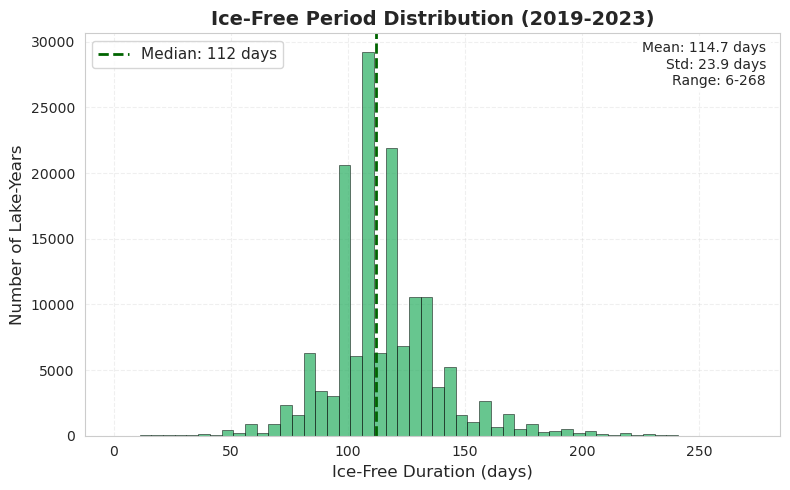

Saved: figures/supplementary/figS03_ice_free_duration.png


In [15]:
# ============================================================
# SUPPLEMENTARY FIGURE S03: Ice-free Duration Distribution
# ============================================================
# Histogram of ice-free period (moved from manuscript Fig 2)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot ice-free duration histogram
bins = np.arange(complete_records['ice_free_days'].min() - 5,
                 complete_records['ice_free_days'].max() + 5, 5)
ax.hist(complete_records['ice_free_days'], bins=bins, alpha=0.7,
        color='#27ae60', edgecolor='black', linewidth=0.5)

# Add median line
median_ifd = complete_records['ice_free_days'].median()
ax.axvline(median_ifd, color='darkgreen', linestyle='--', linewidth=2,
           label=f'Median: {median_ifd:.0f} days')

# Labels
ax.set_xlabel('Ice-Free Duration (days)', fontsize=12)
ax.set_ylabel('Number of Lake-Years', fontsize=12)
ax.set_title('Ice-Free Period Distribution (2019-2023)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Stats annotation
stats_text = (f"Mean: {complete_records['ice_free_days'].mean():.1f} days\n"
              f"Std: {complete_records['ice_free_days'].std():.1f} days\n"
              f"Range: {complete_records['ice_free_days'].min():.0f}-{complete_records['ice_free_days'].max():.0f}")
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
os.makedirs('./figures/supplementary', exist_ok=True)
plt.savefig('./figures/supplementary/figS03_ice_free_duration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS03_ice_free_duration.png")

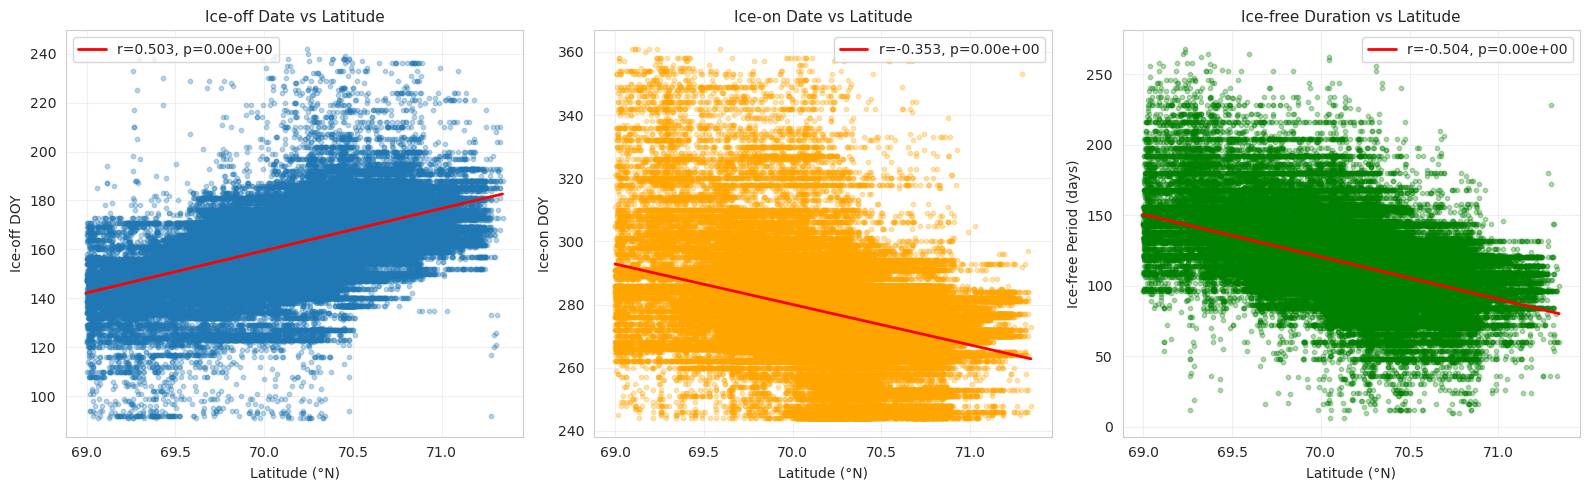

Saved: figures/working/latitude_phenology_correlations.png

Latitude correlations:
  Ice-off DOY: r = -0.504


In [16]:
# Figure 2: Latitude relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
from scipy import stats

# Ice-off vs latitude
ax = axes[0]
ax.scatter(complete_records['centroid_lat'], complete_records['ice_off_doy'], alpha=0.3, s=10)
mask = complete_records['centroid_lat'].notna() & complete_records['ice_off_doy'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete_records.loc[mask, 'centroid_lat'], 
    complete_records.loc[mask, 'ice_off_doy']
)
x_line = np.linspace(complete_records['centroid_lat'].min(), complete_records['centroid_lat'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-off DOY')
ax.set_title('Ice-off Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-on vs latitude
ax = axes[1]
ax.scatter(complete_records['centroid_lat'], complete_records['ice_on_doy'], alpha=0.3, s=10, color='orange')
mask = complete_records['centroid_lat'].notna() & complete_records['ice_on_doy'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete_records.loc[mask, 'centroid_lat'], 
    complete_records.loc[mask, 'ice_on_doy']
)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-on DOY')
ax.set_title('Ice-on Date vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-free days vs latitude
ax = axes[2]
ax.scatter(complete_records['centroid_lat'], complete_records['ice_free_days'], alpha=0.3, s=10, color='green')
mask = complete_records['centroid_lat'].notna() & complete_records['ice_free_days'].notna()
slope, intercept, r, p, se = stats.linregress(
    complete_records.loc[mask, 'centroid_lat'], 
    complete_records.loc[mask, 'ice_free_days']
)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/working/latitude_phenology_correlations.png', dpi=150, bbox_inches='tight')
# Figure 5 moved to notebook 04
plt.show()

print("Saved: figures/working/latitude_phenology_correlations.png")
print(f"\nLatitude correlations:")
print(f"  Ice-off DOY: r = {r:.3f}")

Creating single-lake time series for Lake 635426...
  Area: 0.058 km²
  SDI: 1.5661097036926677


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


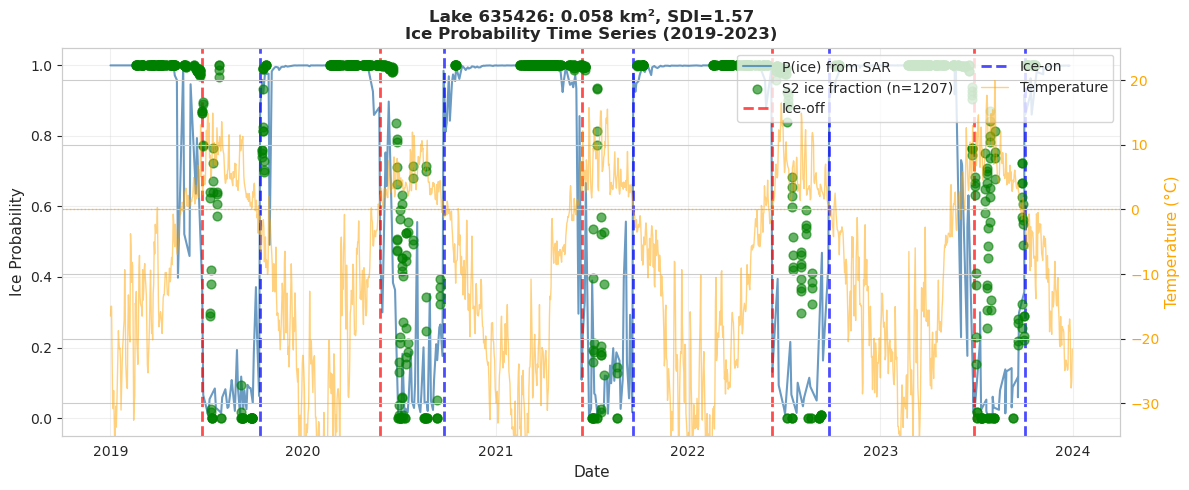


Saved: figures/manuscript/fig03_example_timeseries.png (300 dpi)
Saved: figure_data/fig03_example_timeseries.csv


In [17]:
# ============================================================
# MANUSCRIPT FIGURE 3: Single Example Lake Time Series
# ============================================================
# Most illustrative lake showing clear ice-off and ice-on transitions
# with good S2 validation coverage

# Lake selection criteria:
# - Clear ice-off and ice-on transitions
# - Good S2 validation coverage
# - Representative timing

# Use Lake 635426 - has excellent S2 coverage (1207 obs),
# medium size (0.058 km²), moderate shape (SDI=1.57)
SINGLE_EXAMPLE_LAKE = 635426

print(f"Creating single-lake time series for Lake {SINGLE_EXAMPLE_LAKE}...")

lake_id = SINGLE_EXAMPLE_LAKE
lake_chunk = morphometry[morphometry['lake_id'] == lake_id]['chunk'].values[0]

# Get lake info
lake_info = morphometry[morphometry['lake_id'] == lake_id].iloc[0]
print(f"  Area: {lake_info['area_km2']:.3f} km²")
print(f"  SDI: {lake_info.get('sdi', lake_info.get('shoreline_dev', 'N/A'))}")

# Collect data across all years
all_s1 = []
all_era5 = []
all_s2 = []

for year in YEARS:
    # Load S1 with predictions
    s1 = load_chunk_data('s1', year, lake_chunk)
    if s1 is not None:
        s1 = create_s1_features(s1)
        s1['lake_id'] = s1['id']
        lake_s1 = s1[s1['lake_id'] == lake_id].copy()
        if len(lake_s1) > 0:
            X = lake_s1[FEATURE_COLS].values
            if np.isnan(X).any():
                X = imputer.fit_transform(X)
            lake_s1['rf_ice_prob'] = rf_model.predict_proba(X)[:, 1]
            all_s1.append(lake_s1[['s1_date', 'rf_ice_prob', 'lake_vv_db']])

    # Load ERA5
    era5 = load_chunk_data('era5', year, lake_chunk)
    if era5 is not None:
        lake_era5 = era5[era5['id'] == lake_id].copy()
        if len(lake_era5) > 0:
            all_era5.append(lake_era5[['era5_date', 'temp_c']])

    # Load S2
    s2 = load_chunk_data('s2', year, lake_chunk)
    if s2 is not None:
        lake_s2 = s2[(s2['id'] == lake_id) & (s2['s2_cloud_pct'] <= 30)].copy()
        if len(lake_s2) > 0:
            all_s2.append(lake_s2[['s2_date', 's2_ice_fraction']])

# Combine data
s1_combined = pd.concat(all_s1, ignore_index=True).sort_values('s1_date')
era5_combined = pd.concat(all_era5, ignore_index=True).sort_values('era5_date') if all_era5 else pd.DataFrame()
s2_combined = pd.concat(all_s2, ignore_index=True).sort_values('s2_date') if all_s2 else pd.DataFrame()

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot ice probability (primary y-axis)
ax.plot(s1_combined['s1_date'], s1_combined['rf_ice_prob'],
        '-', color='steelblue', linewidth=1.5, alpha=0.8, label='P(ice) from SAR')

# Plot S2 ice fraction (green dots)
if len(s2_combined) > 0:
    ax.scatter(s2_combined['s2_date'], s2_combined['s2_ice_fraction'],
               s=40, marker='o', color='green', alpha=0.6,
               label=f'S2 ice fraction (n={len(s2_combined)})', zorder=5)

# Get phenology dates for this lake
lake_pheno = complete_records[complete_records['lake_id'] == lake_id]

# Plot ice-off (red dashed) and ice-on (blue dashed) for ALL years
first_ice_off = True
first_ice_on = True
for _, row in lake_pheno.iterrows():
    if pd.notna(row['ice_off_date']):
        ax.axvline(row['ice_off_date'], color='red', linestyle='--',
                   linewidth=2, alpha=0.7, label='Ice-off' if first_ice_off else None)
        first_ice_off = False
    if pd.notna(row['ice_on_date']):
        ax.axvline(row['ice_on_date'], color='blue', linestyle='--',
                   linewidth=2, alpha=0.7, label='Ice-on' if first_ice_on else None)
        first_ice_on = False

# Secondary y-axis for temperature
ax2 = ax.twinx()
if len(era5_combined) > 0:
    ax2.plot(era5_combined['era5_date'], era5_combined['temp_c'],
             '-', color='orange', linewidth=1, alpha=0.5, label='Temperature')
    ax2.axhline(0, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax2.set_ylabel('Temperature (°C)', color='orange', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(-35, 25)

# Configure primary axis
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel('Ice Probability', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.grid(True, alpha=0.3)

# Title
sdi_val = lake_info.get('sdi', lake_info.get('shoreline_dev', 0))
ax.set_title(f"Lake {lake_id}: {lake_info['area_km2']:.3f} km², SDI={sdi_val:.2f}\n"
             f"Ice Probability Time Series (2019-2023)", fontsize=12, fontweight='bold')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels() if len(era5_combined) > 0 else ([], [])
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()

# Save
plt.savefig('./figures/manuscript/fig03_example_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# Export figure data
fig3_data = s1_combined.copy()
fig3_data['lake_id'] = lake_id
fig3_data.to_csv('figure_data/fig03_example_timeseries.csv', index=False)

print("\nSaved: figures/manuscript/fig03_example_timeseries.png (300 dpi)")
print("Saved: figure_data/fig03_example_timeseries.csv")

Creating 6-lake time series grid for supplementary figure...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


...

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


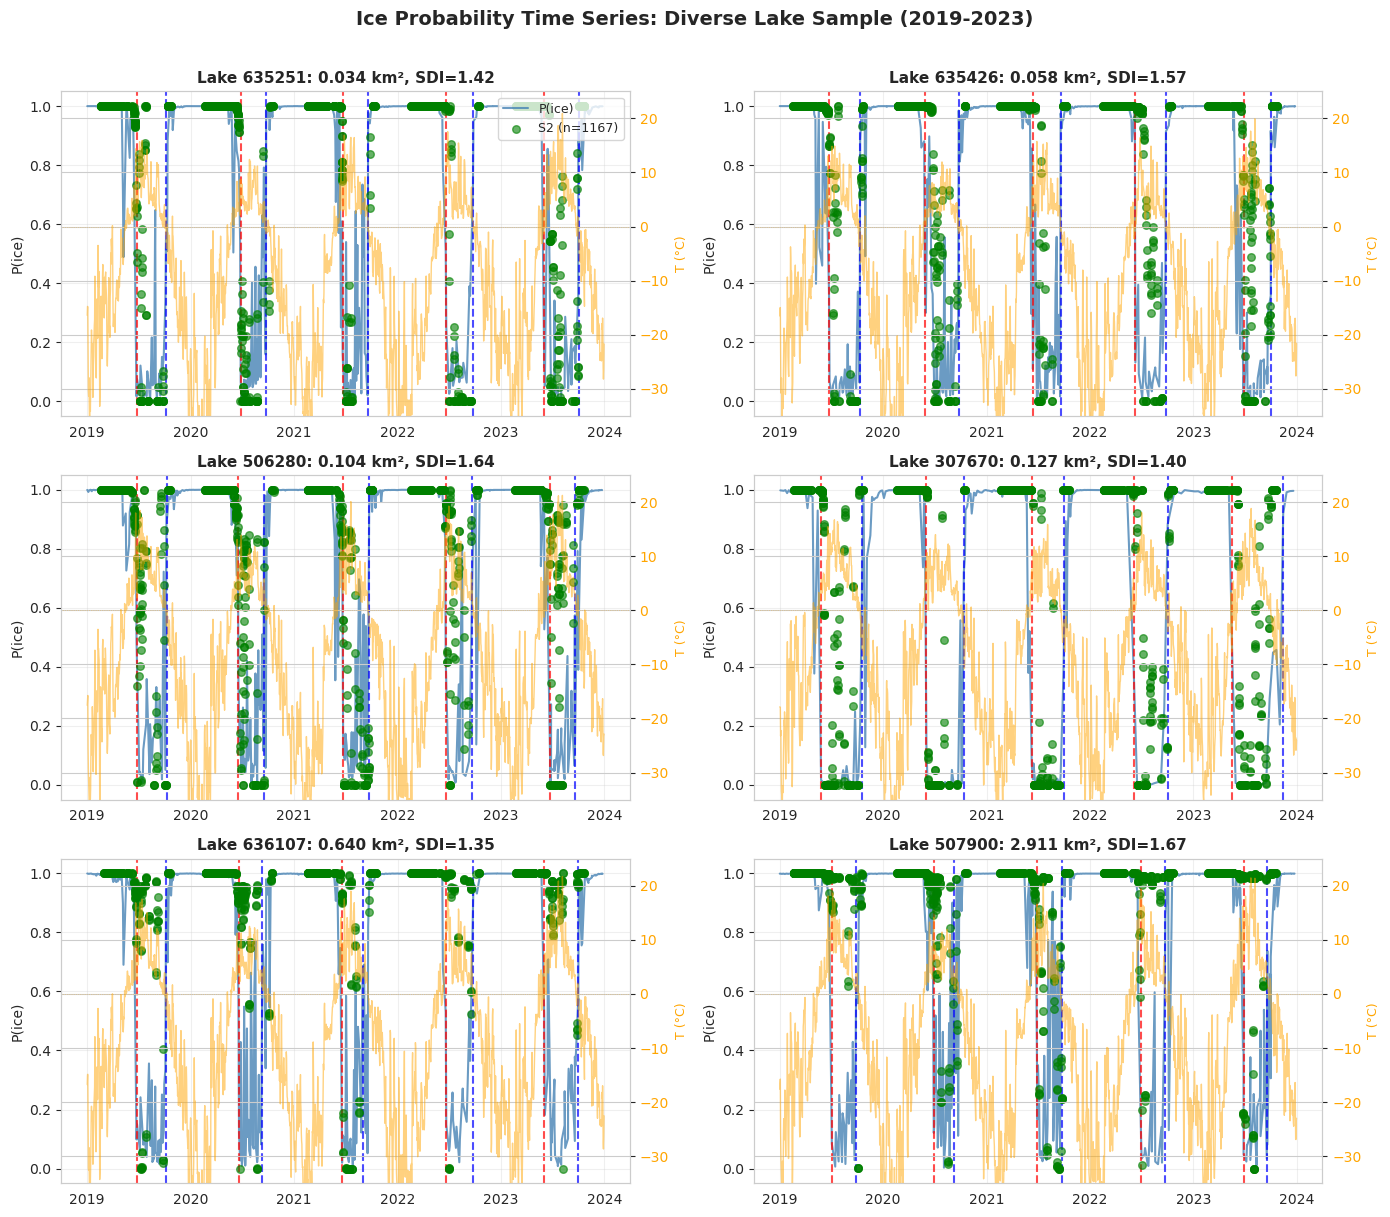

Saved: figures/supplementary/figS04_lake_timeseries_grid.png


In [18]:
# ============================================================
# SUPPLEMENTARY FIGURE S04: 6-Lake Time Series Grid
# ============================================================
# Diverse lake sample showing ice probability time series
# (Expanded version of manuscript Figure 3)

# Pre-selected lakes with excellent S2 coverage
SELECTED_LAKES = [635251, 635426, 506280, 307670, 636107, 507900]

print("Creating 6-lake time series grid for supplementary figure...")

# Get lake info
lake_info_df = morphometry[morphometry['lake_id'].isin(SELECTED_LAKES)].copy()
lake_info_df = lake_info_df.sort_values('area_km2')

# Create figure (3 rows x 2 columns = 6 panels)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, lake_id in enumerate(lake_info_df['lake_id'].values):
    if idx >= 6:
        break

    ax = axes[idx]
    lake_info = lake_info_df[lake_info_df['lake_id'] == lake_id].iloc[0]
    lake_chunk = int(lake_info['chunk'])  # Cast to int for formatting

    # Collect data across all years
    all_s1 = []
    all_era5 = []
    all_s2 = []

    for year in YEARS:
        s1 = load_chunk_data('s1', year, lake_chunk)
        if s1 is not None:
            s1 = create_s1_features(s1)
            s1['lake_id'] = s1['id']
            lake_s1 = s1[s1['lake_id'] == lake_id].copy()
            if len(lake_s1) > 0:
                X = lake_s1[FEATURE_COLS].values
                if np.isnan(X).any():
                    X = imputer.fit_transform(X)
                lake_s1['rf_ice_prob'] = rf_model.predict_proba(X)[:, 1]
                all_s1.append(lake_s1[['s1_date', 'rf_ice_prob']])

        era5 = load_chunk_data('era5', year, lake_chunk)
        if era5 is not None:
            lake_era5 = era5[era5['id'] == lake_id].copy()
            if len(lake_era5) > 0:
                all_era5.append(lake_era5[['era5_date', 'temp_c']])

        s2 = load_chunk_data('s2', year, lake_chunk)
        if s2 is not None:
            lake_s2 = s2[(s2['id'] == lake_id) & (s2['s2_cloud_pct'] <= 30)].copy()
            if len(lake_s2) > 0:
                all_s2.append(lake_s2[['s2_date', 's2_ice_fraction']])

    if not all_s1:
        continue

    s1_combined = pd.concat(all_s1, ignore_index=True).sort_values('s1_date')
    era5_combined = pd.concat(all_era5, ignore_index=True).sort_values('era5_date') if all_era5 else pd.DataFrame()
    s2_combined = pd.concat(all_s2, ignore_index=True).sort_values('s2_date') if all_s2 else pd.DataFrame()

    # Plot
    ax.plot(s1_combined['s1_date'], s1_combined['rf_ice_prob'],
            '-', color='steelblue', linewidth=1.5, alpha=0.8, label='P(ice)')

    if len(s2_combined) > 0:
        ax.scatter(s2_combined['s2_date'], s2_combined['s2_ice_fraction'],
                   s=30, marker='o', color='green', alpha=0.6,
                   label=f'S2 (n={len(s2_combined)})', zorder=5)

    # Get phenology dates
    lake_pheno = complete_records[complete_records['lake_id'] == lake_id]
    for _, row in lake_pheno.iterrows():
        if pd.notna(row.get('ice_off_date')):
            ax.axvline(row['ice_off_date'], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        if pd.notna(row.get('ice_on_date')):
            ax.axvline(row['ice_on_date'], color='blue', linestyle='--', linewidth=1.5, alpha=0.7)

    # Temperature on secondary axis
    ax2 = ax.twinx()
    if len(era5_combined) > 0:
        ax2.plot(era5_combined['era5_date'], era5_combined['temp_c'],
                 '-', color='orange', linewidth=1, alpha=0.5)
        ax2.axhline(0, color='orange', linestyle=':', linewidth=0.5, alpha=0.5)
        ax2.set_ylabel('T (°C)', color='orange', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='orange')
        ax2.set_ylim(-35, 25)

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(ice)', fontsize=10)
    ax.grid(True, alpha=0.3)

    sdi_val = lake_info.get('sdi', lake_info.get('shoreline_dev', 0))
    ax.set_title(f"Lake {lake_id}: {lake_info['area_km2']:.3f} km², SDI={sdi_val:.2f}",
                 fontsize=11, fontweight='bold')

    if idx == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        ax.legend(lines1, labels1, loc='upper right', fontsize=9)

plt.suptitle('Ice Probability Time Series: Diverse Lake Sample (2019-2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./figures/supplementary/figS04_lake_timeseries_grid.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/supplementary/figS04_lake_timeseries_grid.png")

In [ ]:
# ============================================================
# SUPPLEMENTARY FIGURE S16: Sentinel-1 Acquisition Time Distribution
# ============================================================
# Histogram of S1 image acquisition times (UTC) by orbit direction,
# plus annual image count showing S1B failure impact.

import re
from collections import defaultdict

print("Extracting S1 acquisition metadata from all chunks...")

# Collect unique S1 image metadata across all chunk/year combinations
image_records = {}  # keyed by image base ID to deduplicate across lakes

for chunk_id in range(NUM_CHUNKS):
    for year in YEARS:
        s1 = load_chunk_data('s1', year, chunk_id)
        if s1 is None or len(s1) == 0:
            continue
        
        for _, row in s1[['system:index', 's1_orbit', 's1_date']].drop_duplicates('system:index').iterrows():
            sid = row['system:index']
            # Extract base image ID (before the lake-specific suffixes)
            base_id = '_'.join(sid.split('_')[:8])
            if base_id not in image_records:
                # Parse acquisition time from system:index
                # Format: S1A_IW_GRDH_1SDV_20190103T171605_...
                match = re.search(r'_(\d{8}T\d{6})_', sid)
                if match:
                    time_str = match.group(1)
                    hour = int(time_str[9:11])
                    minute = int(time_str[11:13])
                    second = int(time_str[13:15])
                    acq_time_hours = hour + minute / 60 + second / 3600
                    acq_year = int(time_str[:4])
                    
                    # Determine satellite (S1A vs S1B)
                    satellite = sid[:3]  # 'S1A' or 'S1B'
                    
                    image_records[base_id] = {
                        'acq_time_hours': acq_time_hours,
                        'orbit': row['s1_orbit'],
                        'year': acq_year,
                        'satellite': satellite
                    }
        
        del s1

import pandas as pd
img_df = pd.DataFrame.from_dict(image_records, orient='index')
print(f"Unique S1 images: {len(img_df):,}")
print(f"  Ascending: {(img_df['orbit'] == 'ASCENDING').sum():,}")
print(f"  Descending: {(img_df['orbit'] == 'DESCENDING').sum():,}")
print(f"  S1A: {(img_df['satellite'] == 'S1A').sum():,}")
print(f"  S1B: {(img_df['satellite'] == 'S1B').sum():,}")

# --- Create 2-panel figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): Acquisition time histogram by orbit direction
bins = np.arange(0, 24.5, 0.5)  # 30-minute bins
asc_times = img_df[img_df['orbit'] == 'ASCENDING']['acq_time_hours']
desc_times = img_df[img_df['orbit'] == 'DESCENDING']['acq_time_hours']

ax1.hist(asc_times, bins=bins, alpha=0.7, color='#e74c3c', edgecolor='black',
         linewidth=0.5, label=f'Ascending (n={len(asc_times):,})')
ax1.hist(desc_times, bins=bins, alpha=0.7, color='#3498db', edgecolor='black',
         linewidth=0.5, label=f'Descending (n={len(desc_times):,})')

ax1.set_xlabel('Acquisition Time (UTC)', fontsize=11)
ax1.set_ylabel('Number of Images', fontsize=11)
ax1.set_title('(a) S1 Acquisition Time Distribution', fontsize=12, fontweight='bold')
ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Add local time annotation (AKST = UTC-9)
ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
akst_ticks = range(0, 25, 3)
akst_labels = [f'{(h - 9) % 24:02d}:00' for h in akst_ticks]
ax1_top.set_xticks(akst_ticks)
ax1_top.set_xticklabels(akst_labels, fontsize=9, color='gray')
ax1_top.set_xlabel('Local Time (AKST, UTC-9)', fontsize=10, color='gray')

# Panel (b): Annual image count by orbit and satellite
year_orbit = img_df.groupby(['year', 'orbit']).size().unstack(fill_value=0)
year_sat = img_df.groupby(['year', 'satellite']).size().unstack(fill_value=0)

x = np.arange(len(YEARS))
width = 0.35

bars1 = ax2.bar(x - width/2, year_orbit.get('ASCENDING', pd.Series(0, index=YEARS)).reindex(YEARS, fill_value=0),
                width, color='#e74c3c', edgecolor='black', linewidth=0.5, label='Ascending')
bars2 = ax2.bar(x + width/2, year_orbit.get('DESCENDING', pd.Series(0, index=YEARS)).reindex(YEARS, fill_value=0),
                width, color='#3498db', edgecolor='black', linewidth=0.5, label='Descending')

             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Number of Images', fontsize=11)
ax2.set_title('(b) Annual S1 Image Count by Orbit', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(YEARS)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('./figures/supplementary/figS16_s1_acquisition_times.png', dpi=300, bbox_inches='tight')
plt.show()

# Export figure data
img_df.to_csv('figure_data/figS16_s1_acquisition_times.csv', index=True)

print("\nSaved: figures/supplementary/figS16_s1_acquisition_times.png (300 dpi)")
print("Saved: figure_data/figS16_s1_acquisition_times.csv")

# Print summary table
print("\nAnnual image counts:")
print(year_orbit.to_string())


In [19]:
# Final memory status
print("="*60)
print("PROCESSING COMPLETE")
print("="*60)

print("\nOutput files:")
print(f"  1. {LOCAL_TIMESERIES_PATH} - Ice probability for all S1 observations")
print(f"  2. {LOCAL_PHENOLOGY_PATH} - Ice phenology for all lake-years")
print(f"  3. {LOCAL_MODEL_PATH} - Trained RF model")
print(f"\nGCS location: {RESULTS_GCS}/")

PROCESSING COMPLETE

Output files:
  1. alaska_lakes_ice_probability_timeseries_2019-2023.csv - Ice probability for all S1 observations
  2. alaska_lakes_ice_phenology_2019-2023.csv - Ice phenology for all lake-years
  3. rf_ice_model.joblib - Trained RF model

GCS location: gs://wustl-eeps-geospatial/thermokarst_lakes/results/
